# LC-DA-CA1 Model

Author: Dinghao Luo  
Date: 31 March 2026

This notebook contains a phenomenological LC-DA-CA1 model used to test whether a simple circuit-level account can reproduce the main PyrUp and PyrDown findings across bootstrapped simulations.

tl;dr: each CA1 pyramidal cell is driven by three time-varying inputs: a run-related excitatory drive, a reward-related suppressive drive, and a dopamine-dependent modulatory drive derived from the pre-run DA dip and LC phasic activity. Cells differ in baseline excitability, coupling weights, dopamine sensitivity, and intrinsic recovery time constant, and are classified as PyrUp or PyrDown from their post/pre firing-rate ratio.

The model is built in four stages.

**1. Build the three drives**

- Run drive, $R(t)$: a smooth positive pulse that begins slightly before run onset, rises toward its peak at about $1\,\mathrm{s}$, and then decays.
- Reward drive, $W(t)$: a smooth negative pulse that suppresses activity after run onset and then recovers.
- Dopamine drive, $D_i^{DA}(t)$: first combine the pre-run DA dip and the LC-triggered DA release,

$$
D_{\mathrm{combined}}(t) = D_{\mathrm{dip}}(t) + D_{\mathrm{release}}(t)
$$

then pass that trace through a DA-effect recovery filter so that the DA signal seen by CA1 rises quickly but decays more slowly,

$$
D_{\mathrm{filt}}(t) = \mathcal{F}_{\tau_D}\!\left[D_{\mathrm{combined}}(t)\right]
$$

and finally scale it for each cell according to its DA sensitivity and activity-dependent DA gate,

$$
g_i = g_{\mathrm{global}} + g_{\mathrm{extra}}
$$

$$
D_i^{DA}(t) = g_i\,\sigma\!\left(\frac{\operatorname{softplus}\!\big(b_i + w_i^R R(t) + w_i^W W(t)\big) - r_{1/2}}{k_r}\right) D_{\mathrm{filt}}(t)
$$

**2. Form the total CA1 drive**

$$
z_i(t) = b_i + w_i^R R(t) + w_i^W W(t) + D_i^{DA}(t)
$$

**3. Apply the intrinsic recovery time constant**

$$
\tau_i \frac{d u_i(t)}{dt} = -u_i(t) + z_i(t)
$$

**4. Rectify the latent state into a firing rate**

$$
r_i(t) = \operatorname{softplus}\!\big(u_i(t)\big)
$$

Symbol definitions:
- $b_i$: baseline excitability of cell $i$
- $w_i^R$: weight on the run-related drive $R(t)$
- $w_i^W$: weight on the reward-related drive $W(t)$
- $g_i$: DA sensitivity of cell $i$
- $\tau_i$: cell-specific intrinsic recovery constant
- $u_i(t)$: latent CA1 state before output rectification
- $r_i(t)$: final firing rate used for classification and plotting

This is a compact phenomenological model rather than a detailed biophysical circuit model. Its purpose is to test whether one coherent LC-DA-CA1 architecture can reproduce the manuscript-level shifts in PyrUp and PyrDown proportions and firing-rate profiles.

In [157]:
# imports
import warnings
import numpy as np
import matplotlib.pyplot as plt

from copy import deepcopy
from dataclasses import dataclass
from pathlib import Path
from scipy.stats import ttest_rel, wilcoxon

import plotting_functions as pf
from common_functions import mpl_formatting
mpl_formatting()

PLOT_SAVE_DIR = Path('Z:/Dinghao/code_dinghao/modelling')
PLOT_SAVE_DIR.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings('ignore', message='Matplotlib is currently using agg')

In [158]:
@dataclass
class PARAMS:
    # simulation grid
    dt: float     = 0.01  # time step
    t_pre: float  = 1.00  # simulation start time (negative) relative to run onset
    t_post: float = 6.00  # simulation end time relative to run onset 

    # bootstrap controls
    n_bootstrap: int          = 20  # how many times to run bootstrapping for each exp?
    seed_start: int           = 0  # which seed to use by default (rng)
    lc_activation_fold: float = 1.50  # optogenetic LC stim. (exp 1) fold

    # population size
    n_cells: int = 1000  # population size 

    # population priors
    baseline_mean: float = 1.50  # CA1 pyramidal baseline mean 
    baseline_sd: float   = 0.35  # CA1 pyramidal baseline std 

    wR_mean: float = 0.49  # run-related coupling mean (absorbs the former run-drive amplitude)
    wR_sd: float   = 0.42
    wW_mean: float = 0.238  # reward-related coupling mean (absorbs the former reward-drive amplitude)
    wW_sd: float   = 0.85

    # additive DA drive
    frac_da_targ: float           = 0.35  # proportion of CA1 cells targeted by DA
    da_half_rate: float           = 2.20  # r_1/2; midpoint of the sigmoid for FR-dependent DA modulation 
    da_rate_slope: float          = 0.45  # k_r; steepness of the sigmoid gate
    da_gain_global: float         = 1.10  # DA sensitivity of the population (diffuse DA effects; small)
    da_gain_targeted_extra: float = 0.64  # DA sensitivity of the DA-targeted population (targeted DA effects; large)
    da_block_scale: float         = 0.60  # 1 - how much DA is blocked in exp 3 

    # combined DA signal -> effective DA drive filter
    da_effect_tau: float          = 2.80  # drag out the DA decay after LC-induced release 
    da_effect_away_scale: float   = 0.03  # this times da_effect_tau = rise_tau; handles rising phase from pre-run dip to DA peak
    da_effect_switch_scale: float = 0.0015  # rising-to-decaying switch smoothness

    # cell-intrinsic recovery acting on the full latent CA1 state
    intrinsic_tau_mean: float = 0.35  # mean of the symmetric CA1 tau distribution
    intrinsic_tau_sd: float   = 0.05
    intrinsic_tau_min: float  = 0.05
    intrinsic_tau_max: float  = 1.00

    # output nonlinearity / output limits
    softplus_beta: float = 2.00
    max_rate: float      = 20.00  # capping CA1 pyramidal cell firing rate 

    # run-drive shape
    run_on_mid: float     = 0.14  # midpoint of the rising sigmoid 
    run_off_mid: float    = 2.00  # midpoint of the falling sigmoid 
    run_rise_scale: float = 0.08  # how sharp is the rise?
    run_fall_scale: float = 0.28  # how sharp is the fall?

    # reward-drive shape
    reward_on_mid: float     = 0.72
    reward_off_mid: float    = 1.80
    reward_rise_scale: float = 0.14
    reward_fall_scale: float = 0.34

    # DA dip timing
    da_dip_t: float      = -0.25
    da_dip_tau: float    = 0.20
    da_dip_on_tau: float = 0.40

    # LC drive shape
    lc_baseline: float = 1.00  # baseline amplitude of LC activity 
    lc_amp: float      = 1.50  # delta(peak, baseline) of LC phasic activity
    lc_mu: float       = 0.00  # centre (relative to run onset)
    lc_sigma: float    = 0.20  # sigma of Gaussian 

    # LC -> DA release conversion
    lc_to_da_gain: float = 1.45  # how much DA is generated by LC phasic activity
    da_tau_decay: float  = 0.28  # DA decay constant (raw trace; different than the transformation)
    da_kernel_order: int = 3  # k=3 in the Erlang function

    # population analysis
    pre_window: tuple  = (-1.00, -0.50)  # this does not matter much, since pre-run-onset activity is usually flat
    post_window: tuple = (0.50, 1.50)  # same as used in real experiments 
    up_thresh: float   = 3 / 2  # same 
    down_thresh: float = 2 / 3  # same

    # numerical safeguard
    eps: float = 1e-6


class_colors = {
    'is_up':    'firebrick',
    'is_other': 'grey',
    'is_down':  'purple'
}

condition_colors = {
    'baseline': '0.35',
    'lc': 'royalblue',
    'blocked': class_colors['is_down'],
    'da_targeted': class_colors['is_up'],
    'not_targeted': '0.45'
}

In [159]:
# helper functions

def window_mask(t, window):
    return (t >= window[0]) & (t < window[1])


def response_strength(rates, t, p):
    '''calculates the response strength'''
    pre_mask  = window_mask(t, p.pre_window)
    post_mask = window_mask(t, p.post_window)
    pre_mean  = np.mean(rates[:, pre_mask], axis=1)
    post_mean = np.mean(rates[:, post_mask], axis=1)
    return post_mean / (pre_mean + p.eps)


def classify_cells(resp, p):
    '''classifies cells and returns one-hot encoding of cell identity as a dict'''
    is_up = resp >= p.up_thresh
    is_down = resp <= p.down_thresh
    return {
        'is_up': is_up,
        'is_down': is_down,
        'is_other': ~(is_up | is_down),
    }


def safe_mean_trace(rate_matrix, mask):
    '''just a masked mean FR profile calculation function; "safe" as it handles some edge cases where a class has no cells'''
    if np.sum(mask) == 0:
        return np.full(rate_matrix.shape[1], np.nan)
    return np.mean(rate_matrix[mask], axis=0)


def sem(values, axis=0):
    values = np.asarray(values, dtype=float)
    count = np.sum(np.isfinite(values), axis=axis)
    spread = np.nanstd(values, axis=axis, ddof=1)
    out = spread / np.sqrt(np.maximum(count, 1))
    if np.isscalar(out):
        return np.nan if count <= 1 else float(out)
    out = np.asarray(out, dtype=float)
    return np.where(count > 1, out, np.nan)


def mean_sem(values):
    values = np.asarray(values, dtype=float)
    return float(np.nanmean(values)), float(sem(values, axis=0))


def plot_mean_sem(ax, t, traces, color, label, linestyle='-', alpha_fill=0.18):
    traces = np.asarray(traces, dtype=float)
    mean_trace = np.nanmean(traces, axis=0)
    sem_trace = sem(traces, axis=0)
    ax.plot(t, mean_trace, color=color, linewidth=2, linestyle=linestyle, label=label)
    ax.fill_between(t, mean_trace - sem_trace, mean_trace + sem_trace, color=color, alpha=alpha_fill, linewidth=0)


def baseline_subtracted_traces(traces, t, window):
    '''for plotting'''
    traces = np.asarray(traces, dtype=float)
    baseline = np.mean(traces[:, window_mask(t, window)], axis=1, keepdims=True)
    return traces - baseline


def print_paired_summary(label, left, right):
    def fmt_p(p):
        if not np.isfinite(p):
            return 'nan'
        if p < 1e-4:
            return '<1e-4'
        return f'{p:.4f}'

    left = np.asarray(left, dtype=float)
    right = np.asarray(right, dtype=float)
    mask = np.isfinite(left) & np.isfinite(right)
    left = left[mask]
    right = right[mask]
    if len(left) == 0:
        print(f'{label}: delta = nan, paired t p = nan, Wilcoxon p = nan')
        return

    t_res = ttest_rel(right, left, nan_policy='omit')
    try:
        w_res = wilcoxon(right, left, zero_method='wilcox', method='approx')
        w_p = float(w_res.pvalue)
    except ValueError:
        w_p = np.nan

    print(
        f'{label}: '
        f'delta = {np.mean(right - left):.2f}, '
        f'paired t p = {fmt_p(float(t_res.pvalue))}, '
        f'Wilcoxon p = {fmt_p(w_p)}'
    )


def set_trace_ylim(ax, *trace_sets, pad_frac=0.08, lower_floor=0.0):
    lows = []
    highs = []
    for traces in trace_sets:
        traces = np.asarray(traces, dtype=float)
        if traces.size == 0:
            continue
        if traces.ndim == 1:
            mean_trace = traces
            sem_trace = np.zeros_like(mean_trace)
        else:
            mean_trace = np.nanmean(traces, axis=0)
            sem_trace = sem(traces, axis=0)
        lows.append(float(np.nanmin(mean_trace - sem_trace)))
        highs.append(float(np.nanmax(mean_trace + sem_trace)))

    if not lows or not highs:
        return

    ymin = min(lows)
    ymax = max(highs)
    span = ymax - ymin
    if not np.isfinite(span) or span <= 0:
        span = max(abs(ymax), 1.0) * 0.1
    pad = span * pad_frac
    ax.set_ylim(max(lower_floor, ymin - pad), ymax + pad)


def paired_ylim(*arrays, lower_floor=0.0, pad_frac=0.35, min_pad=2.5, anchor_floor=None):
    finite = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float).ravel()
        arr = arr[np.isfinite(arr)]
        if arr.size:
            finite.append(arr)
    if not finite:
        return None
    values = np.concatenate(finite)
    vmin = float(np.min(values))
    vmax = float(np.max(values))
    span = vmax - vmin
    pad = max(span * pad_frac, min_pad)
    ymin = vmin - pad
    if anchor_floor is not None:
        ymin = min(float(anchor_floor), ymin)
    return (max(lower_floor, ymin), vmax + pad)


def sigmoid(x, midpoint, scale):
    scale = max(scale, 1e-6)
    return 1.0 / (1.0 + np.exp(-(x - midpoint) / scale))


def softplus(x, beta):
    xb = beta * np.asarray(x, dtype=float)
    return (np.log1p(np.exp(-np.abs(xb))) + np.maximum(xb, 0.0)) / beta


def smooth_pulse(tt, onset_mid, offset_mid, rise_scale, fall_scale, eps):
    '''main function producing run- and reward-related drives'''
    pulse = sigmoid(tt, onset_mid, rise_scale) * (1.0 - sigmoid(tt, offset_mid, fall_scale))
    peak = np.max(pulse)
    if peak <= eps:
        return np.zeros_like(tt, dtype=float)
    return pulse / peak


def erlang_kernel(dt, tau, order, t_max, eps):
    '''for modelling DA drive'''
    tau = max(float(tau), float(eps))
    order = max(int(order), 1)
    tk = np.arange(0.0, t_max + dt, dt)
    x = tk / tau
    k = (x ** (order - 1)) * np.exp(-x)
    if len(k):
        k[0] = 0.0
    k /= np.sum(k) * dt + eps
    return k


def exponential_dip(tt, t_pre, dip_t, dip_on_tau, eps):
    '''for modelling DA dip'''
    dip_floor = -0.50
    down_mask = tt <= dip_t
    T = dip_t + t_pre
    tau = max(float(dip_on_tau), float(eps))
    s = np.clip(tt[down_mask] + t_pre, 0.0, None)
    denom = 1.0 - np.exp(-max(T, float(eps)) / tau)
    out = np.zeros_like(tt, dtype=float)
    out[down_mask] = dip_floor * (1.0 - np.exp(-s / tau)) / max(denom, float(eps))
    return out


def apply_trace_decay(target_trace, tau_intr, tau_away_scale, dt, switch_scale):
    '''apply decay constants to full trace'''
    target_trace = np.asarray(target_trace, dtype=float)
    out = np.zeros_like(target_trace)
    out[0] = target_trace[0]
    tau_return = max(float(tau_intr), 1e-6)
    tau_away = max(float(tau_intr) * float(tau_away_scale), 1e-6)
    switch_scale = max(float(switch_scale), 1e-6)

    for k in range(1, len(target_trace)):
        target = target_trace[k]
        prev = out[k - 1]
        delta = target - target_trace[k - 1]
        w_rise = 1.0 / (1.0 + np.exp(-delta / switch_scale))
        tau_eff = tau_return * (1.0 - w_rise) + tau_away * w_rise
        alpha = np.clip(dt / max(tau_eff, 1e-6), 0.0, 1.0)
        out[k] = prev + alpha * (target - prev)

    return out


def make_drives(t, p):
    '''returns all the drives to a CA1 cell as a dict'''
    R = smooth_pulse(t, p.run_on_mid, p.run_off_mid, p.run_rise_scale, p.run_fall_scale, p.eps)
    W = -smooth_pulse(t, p.reward_on_mid, p.reward_off_mid, p.reward_rise_scale, p.reward_fall_scale, p.eps)

    D_dip = exponential_dip(t, p.t_pre, p.da_dip_t, p.da_dip_on_tau, p.eps)
    dip_floor = float(np.min(D_dip))
    dip_recover_mask = t > p.da_dip_t
    D_dip[dip_recover_mask] = dip_floor * np.exp(-(t[dip_recover_mask] - p.da_dip_t) / p.da_dip_tau)

    L = p.lc_baseline + p.lc_amp * np.exp(-0.5 * ((t - p.lc_mu) / p.lc_sigma) ** 2)
    lc_excess = np.maximum(L - p.lc_baseline, 0.0)
    k = erlang_kernel(p.dt, p.da_tau_decay, p.da_kernel_order, p.t_pre + p.t_post, p.eps)
    D_release = p.lc_to_da_gain * np.convolve(lc_excess, k, mode='full')[: len(t)] * p.dt
    D_combined = D_dip + D_release
    D = apply_trace_decay(D_combined, p.da_effect_tau, p.da_effect_away_scale, p.dt, p.da_effect_switch_scale)

    return {
        'R': R,
        'W': W,
        'D': D,
        'L': L,
        'D_dip': D_dip,
        'D_release': D_release,
        'D_combined': D_combined,
    }

In [160]:
# simulation functions

def apply_intrinsic_decay_matrix(target_matrix, tau_intr, dt):
    out = np.zeros_like(target_matrix)
    out[:, 0] = target_matrix[:, 0]  # initial condition 
    alpha = np.clip(dt / tau_intr, 0.0, 1.0)

    for k in range(1, target_matrix.shape[1]):
        target = target_matrix[:, k]
        prev = out[:, k - 1]
        out[:, k] = prev + alpha * (target - prev)

    return out


def make_population(p, rng):
    da_targ = rng.random(p.n_cells) < p.frac_da_targ
    return {
        'b':  rng.normal(p.baseline_mean, p.baseline_sd, p.n_cells),
        'wR': rng.normal(p.wR_mean, p.wR_sd, p.n_cells),
        'wW': rng.normal(p.wW_mean, p.wW_sd, p.n_cells),
        'tau_intr': np.clip(
            rng.normal(p.intrinsic_tau_mean, p.intrinsic_tau_sd, p.n_cells),
            p.intrinsic_tau_min,
            p.intrinsic_tau_max,
        ),
        'da_targ': da_targ,
    }


def simulate_population_condition(t, p, pop, da_scale=1.0):
    drives = make_drives(t, p)
    x = (
        pop['b'][:, None]
        + pop['wR'][:, None] * drives['R'][None, :]
        + pop['wW'][:, None] * drives['W'][None, :]
    )

    r_no_da = softplus(x, p.softplus_beta)
    m = sigmoid(r_no_da, p.da_half_rate, p.da_rate_slope)
    da_strength = p.da_gain_global + pop['da_targ'][:, None].astype(float) * p.da_gain_targeted_extra
    state_target = x + da_scale * da_strength * m * drives['D'][None, :]

    latent_state = apply_intrinsic_decay_matrix(
        state_target,
        pop['tau_intr'],
        p.dt,
    )
    rates = np.clip(softplus(latent_state, p.softplus_beta), 0.0, p.max_rate)

    resp = response_strength(rates, t, p)
    classes = classify_cells(resp, p)
    return {
        't': t,
        'drives': drives,
        'rates': rates,
        'resp': resp,
        'classes': classes,
        'mean_traces': {
            'all': np.mean(rates, axis=0),
            'is_up': safe_mean_trace(rates, classes['is_up']),
            'is_other': safe_mean_trace(rates, classes['is_other']),
            'is_down': safe_mean_trace(rates, classes['is_down']),
        },
    }


def run_bootstrap_suite(p):
    t = np.arange(-p.t_pre, p.t_post, p.dt)
    post_mask = window_mask(t, p.post_window)

    p_lc = deepcopy(p)
    p_lc.lc_amp = p.lc_amp * p.lc_activation_fold

    base_all_traces = []
    lc_all_traces = []
    block_all_traces = []
    base_up_traces = []
    lc_up_traces = []
    block_up_traces = []
    base_down_traces = []
    lc_down_traces = []
    block_down_traces = []
    da_up_traces = []
    non_da_up_traces = []
    da_down_traces = []
    non_da_down_traces = []

    stats = {
        'base_up_pct': [],
        'base_down_pct': [],
        'lc_up_pct': [],
        'lc_down_pct': [],
        'block_up_pct': [],
        'block_down_pct': [],
        'p_up_da_targeted': [],
        'p_up_not_targeted': [],
        'p_down_da_targeted': [],
        'p_down_not_targeted': [],
        'post_rate_da_up': [],
        'post_rate_non_da_up': [],
    }

    for seed in range(p.seed_start, p.seed_start + p.n_bootstrap):
        rng = np.random.default_rng(seed)
        pop = make_population(p, rng)

        base  = simulate_population_condition(t, p, pop, da_scale=1.0)  # LC base activity 
        lc    = simulate_population_condition(t, p_lc, pop, da_scale=1.0)  # LC optogenetic
        block = simulate_population_condition(t, p, pop, da_scale=p.da_block_scale)  # DA blockade experiment 

        base_all_traces.append(base['mean_traces']['all'])
        lc_all_traces.append(lc['mean_traces']['all'])
        block_all_traces.append(block['mean_traces']['all'])
        base_up_traces.append(base['mean_traces']['is_up'])
        lc_up_traces.append(lc['mean_traces']['is_up'])
        block_up_traces.append(block['mean_traces']['is_up'])
        base_down_traces.append(base['mean_traces']['is_down'])
        lc_down_traces.append(lc['mean_traces']['is_down'])
        block_down_traces.append(block['mean_traces']['is_down'])

        da_mask = pop['da_targ']
        not_da_mask = ~da_mask
        da_up_mask = da_mask & base['classes']['is_up']
        non_da_up_mask = not_da_mask & base['classes']['is_up']
        da_down_mask = da_mask & base['classes']['is_down']
        non_da_down_mask = not_da_mask & base['classes']['is_down']
        da_up_traces.append(safe_mean_trace(base['rates'], da_up_mask))
        non_da_up_traces.append(safe_mean_trace(base['rates'], non_da_up_mask))
        da_down_traces.append(safe_mean_trace(base['rates'], da_down_mask))
        non_da_down_traces.append(safe_mean_trace(base['rates'], non_da_down_mask))

        stats['base_up_pct'].append(100 * np.mean(base['classes']['is_up']))
        stats['base_down_pct'].append(100 * np.mean(base['classes']['is_down']))
        stats['lc_up_pct'].append(100 * np.mean(lc['classes']['is_up']))
        stats['lc_down_pct'].append(100 * np.mean(lc['classes']['is_down']))
        stats['block_up_pct'].append(100 * np.mean(block['classes']['is_up']))
        stats['block_down_pct'].append(100 * np.mean(block['classes']['is_down']))
        stats['p_up_da_targeted'].append(100 * np.mean(base['classes']['is_up'][da_mask]))
        stats['p_up_not_targeted'].append(100 * np.mean(base['classes']['is_up'][not_da_mask]))
        stats['p_down_da_targeted'].append(100 * np.mean(base['classes']['is_down'][da_mask]))
        stats['p_down_not_targeted'].append(100 * np.mean(base['classes']['is_down'][not_da_mask]))
        stats['post_rate_da_up'].append(np.mean(base['rates'][da_up_mask][:, post_mask]) if np.any(da_up_mask) else np.nan)
        stats['post_rate_non_da_up'].append(np.mean(base['rates'][non_da_up_mask][:, post_mask]) if np.any(non_da_up_mask) else np.nan)

    stats = {key: np.asarray(value, dtype=float) for key, value in stats.items()}
    return {
        't': t,
        'params': p,
        'base_drives': make_drives(t, p),
        'base_all_traces': np.asarray(base_all_traces, dtype=float),
        'lc_all_traces': np.asarray(lc_all_traces, dtype=float),
        'block_all_traces': np.asarray(block_all_traces, dtype=float),
        'base_up_traces': np.asarray(base_up_traces, dtype=float),
        'lc_up_traces': np.asarray(lc_up_traces, dtype=float),
        'block_up_traces': np.asarray(block_up_traces, dtype=float),
        'base_down_traces': np.asarray(base_down_traces, dtype=float),
        'lc_down_traces': np.asarray(lc_down_traces, dtype=float),
        'block_down_traces': np.asarray(block_down_traces, dtype=float),
        'da_up_traces': np.asarray(da_up_traces, dtype=float),
        'non_da_up_traces': np.asarray(non_da_up_traces, dtype=float),
        'da_down_traces': np.asarray(da_down_traces, dtype=float),
        'non_da_down_traces': np.asarray(non_da_down_traces, dtype=float),
        'stats': stats,
    }

In [161]:
# run the paired synthetic-population bootstrap suite
p = PARAMS()
results = run_bootstrap_suite(p)


def print_summary_line(label, values):
    mean_v, sem_v = mean_sem(values)
    print(f'{label}: {mean_v:.2f} +/- {sem_v:.2f} SEM')


base_up_mean = np.nanmean(results['base_up_traces'], axis=0)
base_all_mean = np.nanmean(results['base_all_traces'], axis=0)
base_release = results['base_drives']['D_release']
base_drive = results['base_drives']['D']
t = results['t']

print('Bootstrap setup:')
print(f'  paired population replicates = {p.n_bootstrap}')
print(f'  cells per replicate = {p.n_cells}')
print(f'  LC activation fold = {p.lc_activation_fold:.2f}x')
print(f'  partial CA1 DA scale = {p.da_block_scale:.2f}')
print()

print('Model diagnostics:')
print(f'  baseline all-cell pre-window mean (Hz) = {np.mean(base_all_mean[window_mask(t, p.pre_window)]):.2f}')
print(f'  baseline PyrUp population peak (Hz) = {np.max(base_up_mean):.2f}')
print(f'  baseline D_release peak time (s) = {t[np.argmax(base_release)]:.2f}')
print(f'  baseline final DA drive peak time (s) = {t[np.argmax(base_drive)]:.2f}')
print(f'  baseline final DA drive at 0.5 s / 1.0 s = {np.interp(0.5, t, base_drive):.2f} / {np.interp(1.0, t, base_drive):.2f}')
print()

print('Key paired summaries (mean +/- SEM):')
print_summary_line('  baseline PyrUp (%)', results['stats']['base_up_pct'])
print_summary_line('  LC-activated PyrUp (%)', results['stats']['lc_up_pct'])
print_paired_summary('  LC activation effect on PyrUp (%)', results['stats']['base_up_pct'], results['stats']['lc_up_pct'])
print_summary_line('  baseline PyrDown (%)', results['stats']['base_down_pct'])
print_summary_line('  LC-activated PyrDown (%)', results['stats']['lc_down_pct'])
print_paired_summary('  LC activation effect on PyrDown (%)', results['stats']['base_down_pct'], results['stats']['lc_down_pct'])
print_summary_line('  partially blocked PyrUp (%)', results['stats']['block_up_pct'])
print_paired_summary('  Partial DA block effect on PyrUp (%)', results['stats']['base_up_pct'], results['stats']['block_up_pct'])
print_summary_line('  partially blocked PyrDown (%)', results['stats']['block_down_pct'])
print_paired_summary('  Partial DA block effect on PyrDown (%)', results['stats']['base_down_pct'], results['stats']['block_down_pct'])
print_summary_line('  P(PyrUp | DA-targeted) (%)', results['stats']['p_up_da_targeted'])
print_summary_line('  P(PyrUp | not targeted) (%)', results['stats']['p_up_not_targeted'])
print_paired_summary('  PyrUp enrichment in DA-targeted cells (%)', results['stats']['p_up_not_targeted'], results['stats']['p_up_da_targeted'])
print_summary_line('  post-run rate, DA-Up (Hz)', results['stats']['post_rate_da_up'])
print_summary_line('  post-run rate, non-DA-Up (Hz)', results['stats']['post_rate_non_da_up'])
print_paired_summary('  Post-run firing-rate difference (Hz)', results['stats']['post_rate_non_da_up'], results['stats']['post_rate_da_up'])


Bootstrap setup:
  paired population replicates = 20
  cells per replicate = 1000
  LC activation fold = 1.50x
  partial CA1 DA scale = 0.60

Model diagnostics:
  baseline all-cell pre-window mean (Hz) = 1.53
  baseline PyrUp population peak (Hz) = 3.17
  baseline D_release peak time (s) = 0.62
  baseline final DA drive peak time (s) = 0.82
  baseline final DA drive at 0.5 s / 1.0 s = 0.80 / 0.84

Key paired summaries (mean +/- SEM):
  baseline PyrUp (%): 40.67 +/- 0.34 SEM
  LC-activated PyrUp (%): 48.36 +/- 0.44 SEM
  LC activation effect on PyrUp (%): delta = 7.69, paired t p = <1e-4, Wilcoxon p = <1e-4
  baseline PyrDown (%): 5.50 +/- 0.12 SEM
  LC-activated PyrDown (%): 4.89 +/- 0.12 SEM
  LC activation effect on PyrDown (%): delta = -0.61, paired t p = <1e-4, Wilcoxon p = <1e-4
  partially blocked PyrUp (%): 33.38 +/- 0.37 SEM
  Partial DA block effect on PyrUp (%): delta = -7.29, paired t p = <1e-4, Wilcoxon p = <1e-4
  partially blocked PyrDown (%): 5.92 +/- 0.14 SEM
  Partial 

## 0. Model Overview

The block below shows the main ingredients of the final model on one reference population: LC activity, the run / reward / final DA drives shown separately, both a baseline-subtracted and a per-cell normalized population heatmap, separate PyrUp and PyrDown population means, and the response-strength tiers within each class.


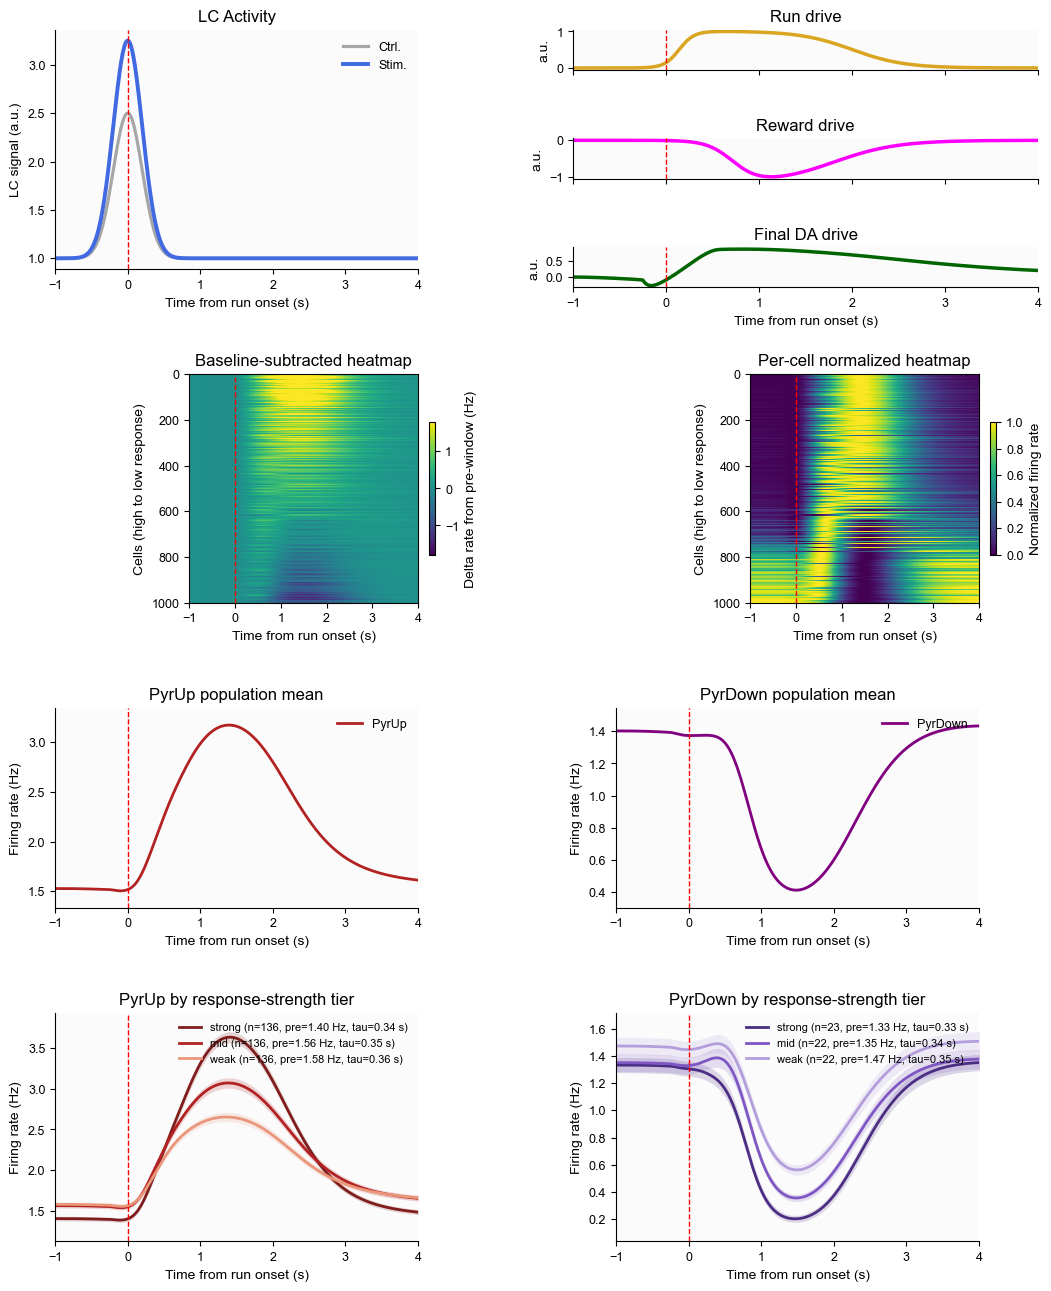

In [162]:
t_ref = results['t']
rng_ref = np.random.default_rng(p.seed_start)
ref_pop = make_population(p, rng_ref)

p_ref_lc = deepcopy(p)
p_ref_lc.lc_amp = p.lc_amp * p.lc_activation_fold

ref_base = simulate_population_condition(t_ref, p, ref_pop, da_scale=1.0)
ref_lc = simulate_population_condition(t_ref, p_ref_lc, ref_pop, da_scale=1.0)

pre_mask = window_mask(t_ref, p.pre_window)
pre_means = np.mean(ref_base['rates'][:, pre_mask], axis=1)
resp = ref_base['resp']
tau_intr = ref_pop['tau_intr']

sort_order = np.argsort(resp)[::-1]
t_mask = (t_ref >= -1.0) & (t_ref <= 4.0)
display_rates = ref_base['rates'][:, t_mask]
heatmap = baseline_subtracted_traces(ref_base['rates'], t_ref, p.pre_window)[sort_order][:, t_mask]
heat_lim = np.nanpercentile(np.abs(heatmap), 97)
if not np.isfinite(heat_lim) or heat_lim <= 0:
    heat_lim = 1.0

row_min = np.nanmin(display_rates, axis=1, keepdims=True)
row_max = np.nanmax(display_rates, axis=1, keepdims=True)
row_span = np.maximum(row_max - row_min, p.eps)
norm_heatmap = ((display_rates - row_min) / row_span)[sort_order]


def tertile_groups(class_mask, values, descending=True):
    idx = np.flatnonzero(class_mask)
    if len(idx) == 0:
        return {'strong': np.array([], dtype=int), 'mid': np.array([], dtype=int), 'weak': np.array([], dtype=int)}
    order = np.argsort(values[idx])
    if descending:
        order = order[::-1]
    ordered = idx[order]
    groups = np.array_split(ordered, 3)
    return {
        'strong': groups[0],
        'mid': groups[1],
        'weak': groups[2],
    }


up_groups = tertile_groups(ref_base['classes']['is_up'], resp, descending=True)
down_groups = tertile_groups(ref_base['classes']['is_down'], resp, descending=False)

up_group_colors = {
    'strong': '#7f1d1d',
    'mid': 'firebrick',
    'weak': '#e9967a',
}

down_group_colors = {
    'strong': '#4b2e83',
    'mid': '#7e57c2',
    'weak': '#b39ddb',
}


def group_label(prefix, idx):
    if len(idx) == 0:
        return f'{prefix} (n=0)'
    return (
        f'{prefix} '
        f'(n={len(idx)}, pre={np.mean(pre_means[idx]):.2f} Hz, tau={np.mean(tau_intr[idx]):.2f} s)'
    )


fig = plt.figure(figsize=(10.4, 12.8), constrained_layout=True)
outer = fig.add_gridspec(4, 2, height_ratios=[1.10, 1.05, 0.92, 1.05], wspace=0.18, hspace=0.14)

a = fig.add_subplot(outer[0, 0])
drive_gs = outer[0, 1].subgridspec(3, 1, hspace=0.10)
b = fig.add_subplot(drive_gs[0, 0])
c = fig.add_subplot(drive_gs[1, 0])
d = fig.add_subplot(drive_gs[2, 0])
e = fig.add_subplot(outer[1, 0])
f = fig.add_subplot(outer[1, 1])
g = fig.add_subplot(outer[2, 0])
h = fig.add_subplot(outer[2, 1])
i = fig.add_subplot(outer[3, 0])
j = fig.add_subplot(outer[3, 1])

for ax in [a, b, c, d, g, h, i, j]:
    ax.set_facecolor('#fbfbfb')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in [e, f]:
    ax.set_facecolor('#fbfbfb')
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_visible(True)

a.plot(t_ref, ref_base['drives']['L'], color='0.65', linewidth=2.3, label='Ctrl.')
a.plot(t_ref, ref_lc['drives']['L'], color='royalblue', linewidth=2.8, label='Stim.')
a.axvline(0, linestyle='--', color='red', linewidth=1)
a.set_xlim([-1.0, 4.0])
a.set_xlabel('Time from run onset (s)')
a.set_ylabel('LC signal (a.u.)')
a.set_title('LC Activity')
a.legend(frameon=False, fontsize=9, loc='upper right')

for ax, key, color, title in [
    (b, 'R', 'goldenrod', 'Run drive'),
    (c, 'W', 'magenta', 'Reward drive'),
    (d, 'D', 'darkgreen', 'Final DA drive'),
]:
    ax.plot(t_ref, ref_base['drives'][key], color=color, linewidth=2.5)
    ax.axvline(0, linestyle='--', color='red', linewidth=1)
    ax.set_xlim([-1.0, 4.0])
    ax.set_ylabel('a.u.')
    ax.set_title(title)

b.set_xticklabels([])
c.set_xticklabels([])
d.set_xlabel('Time from run onset (s)')

im0 = e.imshow(
    heatmap,
    aspect='auto',
    cmap='viridis',
    extent=[t_ref[t_mask][0], t_ref[t_mask][-1], heatmap.shape[0], 0],
    vmin=-heat_lim,
    vmax=heat_lim,
    interpolation='nearest',
)
e.axvline(0, linestyle='--', color='red', linewidth=1)
e.set_xlim([-1.0, 4.0])
e.set_xlabel('Time from run onset (s)')
e.set_ylabel('Cells (high to low response)')
e.set_title('Baseline-subtracted heatmap')
e.set_box_aspect(1)
cbar0 = fig.colorbar(im0, ax=e, shrink=0.58, pad=0.02)
cbar0.set_label('Delta rate from pre-window (Hz)')

im1 = f.imshow(
    norm_heatmap,
    aspect='auto',
    cmap='viridis',
    extent=[t_ref[t_mask][0], t_ref[t_mask][-1], norm_heatmap.shape[0], 0],
    vmin=0.0,
    vmax=1.0,
    interpolation='nearest',
)
f.axvline(0, linestyle='--', color='red', linewidth=1)
f.set_xlim([-1.0, 4.0])
f.set_xlabel('Time from run onset (s)')
f.set_ylabel('Cells (high to low response)')
f.set_title('Per-cell normalized heatmap')
f.set_box_aspect(1)
cbar1 = fig.colorbar(im1, ax=f, shrink=0.58, pad=0.02)
cbar1.set_label('Normalized firing rate')

plot_mean_sem(g, t_ref, results['base_up_traces'], class_colors['is_up'], 'PyrUp')
g.axvline(0, linestyle='--', color='red', linewidth=1)
g.set_xlim([-1.0, 4.0])
set_trace_ylim(g, results['base_up_traces'], pad_frac=0.10, lower_floor=0.0)
g.set_xlabel('Time from run onset (s)')
g.set_ylabel('Firing rate (Hz)')
g.set_title('PyrUp population mean')
g.legend(frameon=False, fontsize=9, loc='upper right')

plot_mean_sem(h, t_ref, results['base_down_traces'], class_colors['is_down'], 'PyrDown')
h.axvline(0, linestyle='--', color='red', linewidth=1)
h.set_xlim([-1.0, 4.0])
set_trace_ylim(h, results['base_down_traces'], pad_frac=0.10, lower_floor=0.0)
h.set_xlabel('Time from run onset (s)')
h.set_ylabel('Firing rate (Hz)')
h.set_title('PyrDown population mean')
h.legend(frameon=False, fontsize=9, loc='upper right')

for key in ['strong', 'mid', 'weak']:
    idx = up_groups[key]
    if len(idx) > 1:
        plot_mean_sem(i, t_ref, ref_base['rates'][idx], up_group_colors[key], group_label(key, idx))
i.axvline(0, linestyle='--', color='red', linewidth=1)
i.set_xlim([-1.0, 4.0])
set_trace_ylim(i, *(ref_base['rates'][idx] for idx in up_groups.values() if len(idx) > 1), pad_frac=0.10, lower_floor=0.0)
i.set_xlabel('Time from run onset (s)')
i.set_ylabel('Firing rate (Hz)')
i.set_title('PyrUp by response-strength tier')
i.legend(frameon=False, fontsize=8, loc='upper right')

for key in ['strong', 'mid', 'weak']:
    idx = down_groups[key]
    if len(idx) > 1:
        plot_mean_sem(j, t_ref, ref_base['rates'][idx], down_group_colors[key], group_label(key, idx))
j.axvline(0, linestyle='--', color='red', linewidth=1)
j.set_xlim([-1.0, 4.0])
set_trace_ylim(j, *(ref_base['rates'][idx] for idx in down_groups.values() if len(idx) > 1), pad_frac=0.10, lower_floor=0.0)
j.set_xlabel('Time from run onset (s)')
j.set_ylabel('Firing rate (Hz)')
j.set_title('PyrDown by response-strength tier')
j.legend(frameon=False, fontsize=8, loc='upper right')

for ext in ['.png', '.pdf']:
    fig.savefig(PLOT_SAVE_DIR / f'general_model_overview{ext}', dpi=300, bbox_inches='tight')

plt.show()


## 0A. FR-Dependent DA Gating

The panel below shows the explicit firing-rate-dependent DA gate, $m(r)$, and the resulting effective DA gain for non-targeted and DA-targeted CA1 cells.


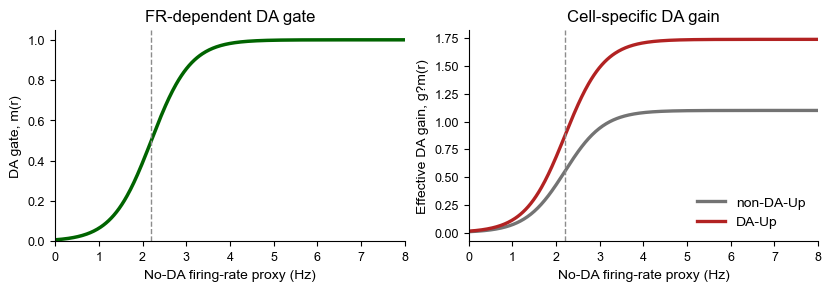

In [163]:
r_grid = np.linspace(0.0, 8.0, 400)
gate_grid = sigmoid(r_grid, p.da_half_rate, p.da_rate_slope)
gain_non_targeted = p.da_gain_global * gate_grid
gain_targeted = (p.da_gain_global + p.da_gain_targeted_extra) * gate_grid

fig, axes = plt.subplots(1, 2, figsize=(8.2, 2.8), constrained_layout=True)

axes[0].plot(r_grid, gate_grid, color='darkgreen', linewidth=2.5)
axes[0].axvline(p.da_half_rate, linestyle='--', color='0.55', linewidth=1)
axes[0].set_xlabel('No-DA firing-rate proxy (Hz)')
axes[0].set_ylabel('DA gate, m(r)')
axes[0].set_title('FR-dependent DA gate')
axes[0].set_xlim([0.0, 8.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(r_grid, gain_non_targeted, color=condition_colors['not_targeted'], linewidth=2.4, label='non-DA-Up')
axes[1].plot(r_grid, gain_targeted, color=condition_colors['da_targeted'], linewidth=2.4, label='DA-Up')
axes[1].axvline(p.da_half_rate, linestyle='--', color='0.55', linewidth=1)
axes[1].set_xlabel('No-DA firing-rate proxy (Hz)')
axes[1].set_ylabel('Effective DA gain, g?m(r)')
axes[1].set_title('Cell-specific DA gain')
axes[1].set_xlim([0.0, 8.0])
axes[1].legend(frameon=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for ext in ['.png', '.pdf']:
    fig.savefig(PLOT_SAVE_DIR / f'general_model_fr_dependent_da_gating{ext}', dpi=300, bbox_inches='tight')

plt.show()


## 0B. Response-Sorted Single-Cell Couplings

The panel below shows the sampled single-cell run and reward couplings, with cells ordered from high to low response strength in the baseline condition. This is a better summary than a generic weight matrix for this model, because the key single-cell heterogeneity is carried by the sampled per-cell couplings $w_R$ and $w_W$.


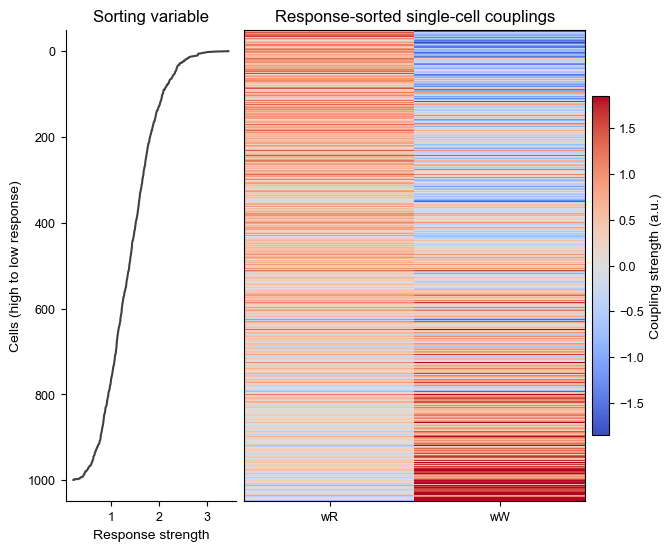

In [164]:
weight_matrix = np.column_stack([
    ref_pop['wR'][sort_order],
    ref_pop['wW'][sort_order],
])
weight_lim = np.nanpercentile(np.abs(weight_matrix), 98)
if not np.isfinite(weight_lim) or weight_lim <= 0:
    weight_lim = 1.0

fig, axes = plt.subplots(1, 2, figsize=(6.6, 5.4), constrained_layout=True, gridspec_kw={'width_ratios': [1.1, 2.2]})

axes[0].plot(resp[sort_order], np.arange(len(sort_order)), color='0.25', linewidth=1.5)
axes[0].invert_yaxis()
axes[0].set_xlabel('Response strength')
axes[0].set_ylabel('Cells (high to low response)')
axes[0].set_title('Sorting variable')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

im = axes[1].imshow(
    weight_matrix,
    aspect='auto',
    cmap='coolwarm',
    vmin=-weight_lim,
    vmax=weight_lim,
    interpolation='nearest',
)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['wR', 'wW'])
axes[1].set_yticks([])
axes[1].set_title('Response-sorted single-cell couplings')

cbar = fig.colorbar(im, ax=axes[1], shrink=0.72, pad=0.02)
cbar.set_label('Coupling strength (a.u.)')

for ext in ['.png', '.pdf']:
    fig.savefig(PLOT_SAVE_DIR / f'general_model_response_sorted_couplings{ext}', dpi=300, bbox_inches='tight')

plt.show()


## 1. Baseline PyrUp and PyrDown Population Means

These panels show the baseline PyrUp and PyrDown population mean firing profiles as `mean +/- SEM` curves.


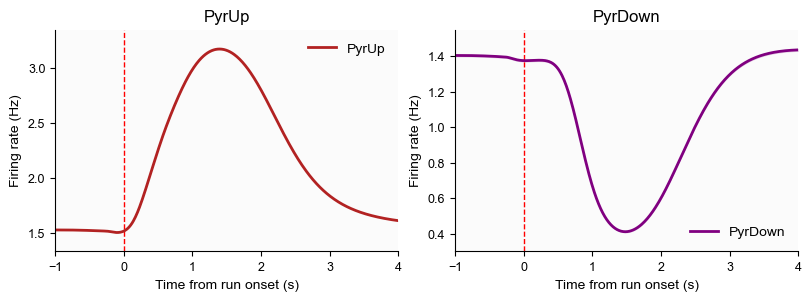

In [165]:
fig, axes = plt.subplots(1, 2, figsize=(8.0, 2.9), constrained_layout=True)

for ax in axes:
    ax.set_facecolor('#fbfbfb')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axvline(0, linestyle='--', color='red', linewidth=1)
    ax.set_xlim([-1.0, 4.0])
    ax.set_xlabel('Time from run onset (s)')
    ax.set_ylabel('Firing rate (Hz)')

plot_mean_sem(axes[0], results['t'], results['base_up_traces'], class_colors['is_up'], 'PyrUp')
set_trace_ylim(axes[0], results['base_up_traces'], pad_frac=0.10, lower_floor=0.0)
axes[0].set_title('PyrUp')
axes[0].legend(frameon=False)

plot_mean_sem(axes[1], results['t'], results['base_down_traces'], class_colors['is_down'], 'PyrDown')
set_trace_ylim(axes[1], results['base_down_traces'], pad_frac=0.10, lower_floor=0.0)
axes[1].set_title('PyrDown')
axes[1].legend(frameon=False)

for ext in ['.png', '.pdf']:
    fig.savefig(PLOT_SAVE_DIR / f'general_model_baseline_pyrup_pyrdown{ext}', dpi=300, bbox_inches='tight')

plt.show()


## 2. LC Activation Profiles for PyrUp and PyrDown

These panels isolate the LC-manipulation effect on PyrUp and PyrDown profiles. Baseline traces are plotted in the class colours, and the `1.5x LC` manipulation is plotted in `royalblue` for both populations.


Wilc p = 1.9073486328125e-06
ttest p = 9.515267633605983e-22
Wilc p = 1.9073486328125e-06
ttest p = 2.1029980844806283e-10


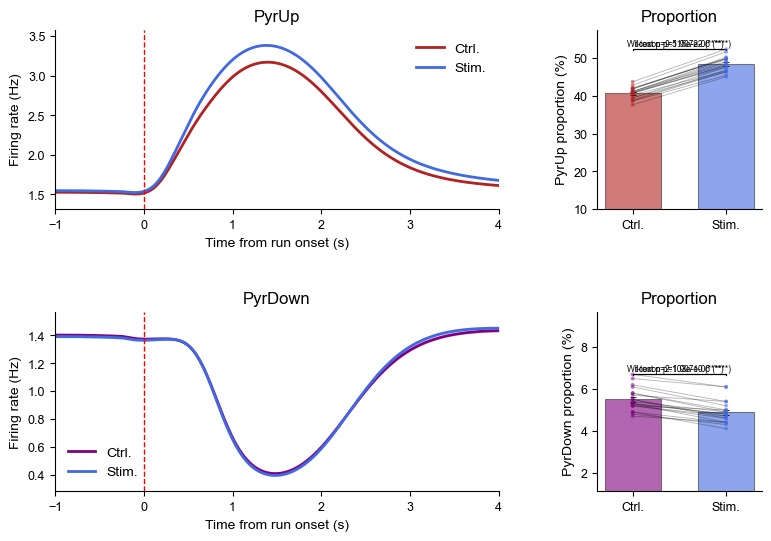

LC activation summary (mean +/- SEM):
  Ctrl. PyrUp (%): 40.67 +/- 0.34 SEM
  Stim. PyrUp (%): 48.36 +/- 0.44 SEM
  PyrUp proportion shift (%): delta = 7.69, paired t p = <1e-4, Wilcoxon p = <1e-4
  Ctrl. PyrDown (%): 5.50 +/- 0.12 SEM
  Stim. PyrDown (%): 4.89 +/- 0.12 SEM
  PyrDown proportion shift (%): delta = -0.61, paired t p = <1e-4, Wilcoxon p = <1e-4


In [166]:
fig = plt.figure(figsize=(7.6, 5.3), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[3.1, 1.15], wspace=0.14, hspace=0.16)
ax_up = fig.add_subplot(gs[0, 0])
ax_down = fig.add_subplot(gs[1, 0])
ax_up_bar = fig.add_subplot(gs[0, 1])
ax_down_bar = fig.add_subplot(gs[1, 1])

plot_mean_sem(ax_up, results['t'], results['base_up_traces'], class_colors['is_up'], 'Ctrl.')
plot_mean_sem(ax_up, results['t'], results['lc_up_traces'], condition_colors['lc'], 'Stim.')
ax_up.axvline(0, linestyle='--', color='red', linewidth=1)
ax_up.set_xlim([-1.0, 4.0])
ax_up.set_xlabel('Time from run onset (s)')
ax_up.set_ylabel('Firing rate (Hz)')
set_trace_ylim(ax_up, results['base_up_traces'], results['lc_up_traces'], pad_frac=0.10, lower_floor=0.0)
ax_up.set_title('PyrUp')
ax_up.legend(frameon=False)
ax_up.spines['top'].set_visible(False)
ax_up.spines['right'].set_visible(False)

plot_mean_sem(ax_down, results['t'], results['base_down_traces'], class_colors['is_down'], 'Ctrl.')
plot_mean_sem(ax_down, results['t'], results['lc_down_traces'], condition_colors['lc'], 'Stim.')
ax_down.axvline(0, linestyle='--', color='red', linewidth=1)
ax_down.set_xlim([-1.0, 4.0])
ax_down.set_xlabel('Time from run onset (s)')
ax_down.set_ylabel('Firing rate (Hz)')
set_trace_ylim(ax_down, results['base_down_traces'], results['lc_down_traces'], pad_frac=0.10, lower_floor=0.0)
ax_down.set_title('PyrDown')
ax_down.legend(frameon=False)
ax_down.spines['top'].set_visible(False)
ax_down.spines['right'].set_visible(False)

pf.plot_bar_with_paired_scatter(
    ax_up_bar,
    results['stats']['base_up_pct'],
    results['stats']['lc_up_pct'],
    colors=(class_colors['is_up'], condition_colors['lc']),
    title='Proportion',
    ylabel='PyrUp proportion (%)',
    xticklabels=('Ctrl.', 'Stim.'),
    ylim=paired_ylim(results['stats']['base_up_pct'], results['stats']['lc_up_pct'], min_pad=3.0, anchor_floor=10.0),
)

pf.plot_bar_with_paired_scatter(
    ax_down_bar,
    results['stats']['base_down_pct'],
    results['stats']['lc_down_pct'],
    colors=(class_colors['is_down'], condition_colors['lc']),
    title='Proportion',
    ylabel='PyrDown proportion (%)',
    xticklabels=('Ctrl.', 'Stim.'),
    ylim=paired_ylim(results['stats']['base_down_pct'], results['stats']['lc_down_pct'], min_pad=3.0, anchor_floor=10.0),
)

for ext in ['.png', '.pdf']:
    fig.savefig(PLOT_SAVE_DIR / f'general_model_experiment_1_lc_activation{ext}', dpi=300, bbox_inches='tight')

plt.show()

print('LC activation summary (mean +/- SEM):')
print_summary_line('  Ctrl. PyrUp (%)', results['stats']['base_up_pct'])
print_summary_line('  Stim. PyrUp (%)', results['stats']['lc_up_pct'])
print_paired_summary('  PyrUp proportion shift (%)', results['stats']['base_up_pct'], results['stats']['lc_up_pct'])
print_summary_line('  Ctrl. PyrDown (%)', results['stats']['base_down_pct'])
print_summary_line('  Stim. PyrDown (%)', results['stats']['lc_down_pct'])
print_paired_summary('  PyrDown proportion shift (%)', results['stats']['base_down_pct'], results['stats']['lc_down_pct'])


## 3. DA-Targeted CA1 Cells

This panel uses the baseline condition only. It compares the DA-targeted and non-targeted subsets within the same synthetic population using the same layout as the other experiments: PyrUp traces, PyrDown traces, PyrUp proportions, and PyrDown proportions.


Wilc p = 1.9073486328125e-06
ttest p = 8.015901213599318e-09
Wilc p = 0.082550048828125
ttest p = 0.11193341262498431


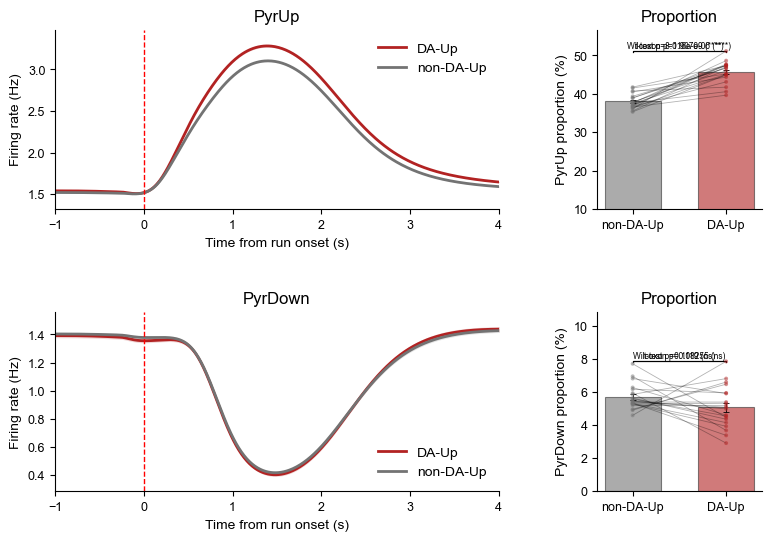

DA-targeting summary (mean +/- SEM):
  P(PyrUp | DA-Up) (%): 45.65 +/- 0.62 SEM
  P(PyrUp | non-DA-Up) (%): 38.03 +/- 0.43 SEM
  PyrUp proportion difference (%): delta = 7.62, paired t p = <1e-4, Wilcoxon p = <1e-4
  P(PyrDown | DA-Up) (%): 5.08 +/- 0.28 SEM
  P(PyrDown | non-DA-Up) (%): 5.71 +/- 0.17 SEM
  PyrDown proportion difference (%): delta = -0.62, paired t p = 0.1119, Wilcoxon p = 0.0793
  Post-run rate, DA-Up (Hz): 2.99 +/- 0.01 SEM
  Post-run rate, non-DA-Up (Hz): 2.82 +/- 0.01 SEM
  Post-run firing-rate difference (Hz): delta = 0.16, paired t p = <1e-4, Wilcoxon p = <1e-4


In [167]:
fig = plt.figure(figsize=(7.6, 5.3), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[3.1, 1.15], wspace=0.14, hspace=0.16)
ax_up = fig.add_subplot(gs[0, 0])
ax_down = fig.add_subplot(gs[1, 0])
ax_up_bar = fig.add_subplot(gs[0, 1])
ax_down_bar = fig.add_subplot(gs[1, 1])

plot_mean_sem(ax_up, results['t'], results['da_up_traces'], condition_colors['da_targeted'], 'DA-Up')
plot_mean_sem(ax_up, results['t'], results['non_da_up_traces'], condition_colors['not_targeted'], 'non-DA-Up')
ax_up.axvline(0, linestyle='--', color='red', linewidth=1)
ax_up.set_xlim([-1.0, 4.0])
ax_up.set_xlabel('Time from run onset (s)')
ax_up.set_ylabel('Firing rate (Hz)')
set_trace_ylim(ax_up, results['da_up_traces'], results['non_da_up_traces'], pad_frac=0.10, lower_floor=0.0)
ax_up.set_title('PyrUp')
ax_up.legend(frameon=False)
ax_up.spines['top'].set_visible(False)
ax_up.spines['right'].set_visible(False)

plot_mean_sem(ax_down, results['t'], results['da_down_traces'], condition_colors['da_targeted'], 'DA-Up')
plot_mean_sem(ax_down, results['t'], results['non_da_down_traces'], condition_colors['not_targeted'], 'non-DA-Up')
ax_down.axvline(0, linestyle='--', color='red', linewidth=1)
ax_down.set_xlim([-1.0, 4.0])
ax_down.set_xlabel('Time from run onset (s)')
ax_down.set_ylabel('Firing rate (Hz)')
set_trace_ylim(ax_down, results['da_down_traces'], results['non_da_down_traces'], pad_frac=0.10, lower_floor=0.0)
ax_down.set_title('PyrDown')
ax_down.legend(frameon=False)
ax_down.spines['top'].set_visible(False)
ax_down.spines['right'].set_visible(False)

pf.plot_bar_with_paired_scatter(
    ax_up_bar,
    results['stats']['p_up_not_targeted'],
    results['stats']['p_up_da_targeted'],
    colors=(condition_colors['not_targeted'], condition_colors['da_targeted']),
    title='Proportion',
    ylabel='PyrUp proportion (%)',
    xticklabels=('non-DA-Up', 'DA-Up'),
    ylim=paired_ylim(results['stats']['p_up_not_targeted'], results['stats']['p_up_da_targeted'], min_pad=3.0, anchor_floor=10.0),
)

pf.plot_bar_with_paired_scatter(
    ax_down_bar,
    results['stats']['p_down_not_targeted'],
    results['stats']['p_down_da_targeted'],
    colors=(condition_colors['not_targeted'], condition_colors['da_targeted']),
    title='Proportion',
    ylabel='PyrDown proportion (%)',
    xticklabels=('non-DA-Up', 'DA-Up'),
    ylim=paired_ylim(results['stats']['p_down_not_targeted'], results['stats']['p_down_da_targeted'], min_pad=3.0, anchor_floor=0.0),
)

for ext in ['.png', '.pdf']:
    fig.savefig(PLOT_SAVE_DIR / f'general_model_experiment_2_da_targeted_subsets{ext}', dpi=300, bbox_inches='tight')

plt.show()

print('DA-targeting summary (mean +/- SEM):')
print_summary_line('  P(PyrUp | DA-Up) (%)', results['stats']['p_up_da_targeted'])
print_summary_line('  P(PyrUp | non-DA-Up) (%)', results['stats']['p_up_not_targeted'])
print_paired_summary('  PyrUp proportion difference (%)', results['stats']['p_up_not_targeted'], results['stats']['p_up_da_targeted'])
print_summary_line('  P(PyrDown | DA-Up) (%)', results['stats']['p_down_da_targeted'])
print_summary_line('  P(PyrDown | non-DA-Up) (%)', results['stats']['p_down_not_targeted'])
print_paired_summary('  PyrDown proportion difference (%)', results['stats']['p_down_not_targeted'], results['stats']['p_down_da_targeted'])
print_summary_line('  Post-run rate, DA-Up (Hz)', results['stats']['post_rate_da_up'])
print_summary_line('  Post-run rate, non-DA-Up (Hz)', results['stats']['post_rate_non_da_up'])
print_paired_summary('  Post-run firing-rate difference (Hz)', results['stats']['post_rate_non_da_up'], results['stats']['post_rate_da_up'])


## 4. Partial DA Blockade in CA1

Within each bootstrap replicate, the DA blockade condition is implemented as a **partial reduction of effective DA efficacy** on the same synthetic population used for baseline. This manipulation scales the effective post-run DA signal inside CA1 rather than changing the pre-run baseline directly.


Wilc p = 1.9073486328125e-06
ttest p = 6.986761654960591e-19
Wilc p = 1.9073486328125e-06
ttest p = 1.1314535166897557e-07


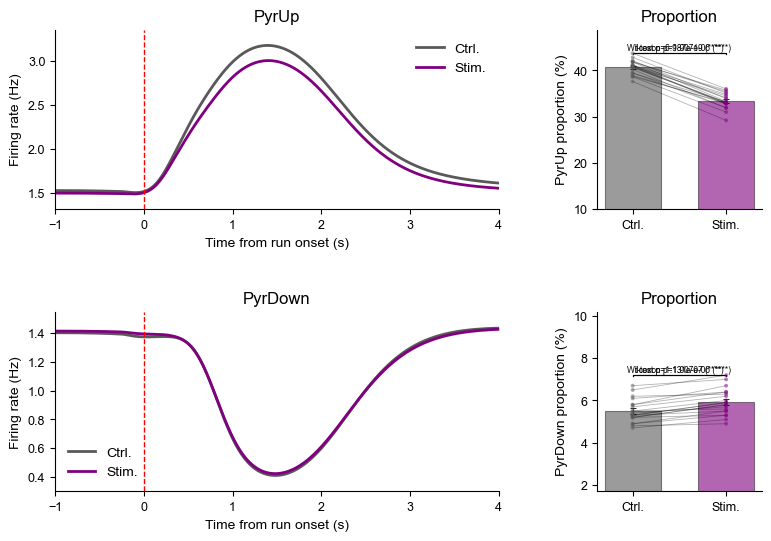

Partial DA blockade summary (mean +/- SEM):
  Ctrl. PyrUp (%): 40.67 +/- 0.34 SEM
  Stim. PyrUp (%): 33.38 +/- 0.37 SEM
  PyrUp proportion shift (%): delta = -7.29, paired t p = <1e-4, Wilcoxon p = <1e-4
  Ctrl. PyrDown (%): 5.50 +/- 0.12 SEM
  Stim. PyrDown (%): 5.92 +/- 0.14 SEM
  PyrDown proportion shift (%): delta = 0.42, paired t p = <1e-4, Wilcoxon p = <1e-4


In [168]:
fig = plt.figure(figsize=(7.6, 5.3), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[3.1, 1.15], wspace=0.14, hspace=0.16)
ax_up = fig.add_subplot(gs[0, 0])
ax_down = fig.add_subplot(gs[1, 0])
ax_up_bar = fig.add_subplot(gs[0, 1])
ax_down_bar = fig.add_subplot(gs[1, 1])

plot_mean_sem(ax_up, results['t'], results['base_up_traces'], condition_colors['baseline'], 'Ctrl.')
plot_mean_sem(ax_up, results['t'], results['block_up_traces'], condition_colors['blocked'], 'Stim.')
ax_up.axvline(0, linestyle='--', color='red', linewidth=1)
ax_up.set_xlim([-1.0, 4.0])
ax_up.set_xlabel('Time from run onset (s)')
ax_up.set_ylabel('Firing rate (Hz)')
set_trace_ylim(ax_up, results['base_up_traces'], results['block_up_traces'], pad_frac=0.10, lower_floor=0.0)
ax_up.set_title('PyrUp')
ax_up.legend(frameon=False)
ax_up.spines['top'].set_visible(False)
ax_up.spines['right'].set_visible(False)

plot_mean_sem(ax_down, results['t'], results['base_down_traces'], condition_colors['baseline'], 'Ctrl.')
plot_mean_sem(ax_down, results['t'], results['block_down_traces'], condition_colors['blocked'], 'Stim.')
ax_down.axvline(0, linestyle='--', color='red', linewidth=1)
ax_down.set_xlim([-1.0, 4.0])
ax_down.set_xlabel('Time from run onset (s)')
ax_down.set_ylabel('Firing rate (Hz)')
set_trace_ylim(ax_down, results['base_down_traces'], results['block_down_traces'], pad_frac=0.10, lower_floor=0.0)
ax_down.set_title('PyrDown')
ax_down.legend(frameon=False)
ax_down.spines['top'].set_visible(False)
ax_down.spines['right'].set_visible(False)

pf.plot_bar_with_paired_scatter(
    ax_up_bar,
    results['stats']['base_up_pct'],
    results['stats']['block_up_pct'],
    colors=(condition_colors['baseline'], condition_colors['blocked']),
    title='Proportion',
    ylabel='PyrUp proportion (%)',
    xticklabels=('Ctrl.', 'Stim.'),
    ylim=paired_ylim(results['stats']['base_up_pct'], results['stats']['block_up_pct'], min_pad=3.0, anchor_floor=10.0),
)

pf.plot_bar_with_paired_scatter(
    ax_down_bar,
    results['stats']['base_down_pct'],
    results['stats']['block_down_pct'],
    colors=(condition_colors['baseline'], condition_colors['blocked']),
    title='Proportion',
    ylabel='PyrDown proportion (%)',
    xticklabels=('Ctrl.', 'Stim.'),
    ylim=paired_ylim(results['stats']['base_down_pct'], results['stats']['block_down_pct'], min_pad=3.0, anchor_floor=10.0),
)

for ext in ['.png', '.pdf']:
    fig.savefig(PLOT_SAVE_DIR / f'general_model_experiment_3_partial_da_block{ext}', dpi=300, bbox_inches='tight')

plt.show()

print('Partial DA blockade summary (mean +/- SEM):')
print_summary_line('  Ctrl. PyrUp (%)', results['stats']['base_up_pct'])
print_summary_line('  Stim. PyrUp (%)', results['stats']['block_up_pct'])
print_paired_summary('  PyrUp proportion shift (%)', results['stats']['base_up_pct'], results['stats']['block_up_pct'])
print_summary_line('  Ctrl. PyrDown (%)', results['stats']['base_down_pct'])
print_summary_line('  Stim. PyrDown (%)', results['stats']['block_down_pct'])
print_paired_summary('  PyrDown proportion shift (%)', results['stats']['base_down_pct'], results['stats']['block_down_pct'])


## Interpretation and Caveats

This notebook should be read as a **phenomenological systems-neuroscience model**, not a detailed biophysical circuit model.

What this final model is meant to provide:
- paired synthetic-population comparisons for baseline, `1.5x` LC activation, and partial DA blockade
- a current-based DA formulation in which dopamine contributes an additive modulatory current before the intrinsic tau update, with `softplus` applied only at the output stage
- a parameter regime that keeps the main experimental effects in range while using fixed class-definition thresholds and a fixed post window
- a compact visual summary of how LC, DA, task drives, and intrinsic recovery combine to shape PyrUp and PyrDown responses

What it does not provide:
- direct uncertainty estimates from the recorded experimental cells
- recurrent CA1 circuitry, receptor-specific DA mechanisms, or trial-to-trial variability
- proof that the biological circuit uses these exact equations or parameter values

The correct interpretation is therefore limited: the model supports the internal logic of the LC-DA-CA1 account and shows that the targeted experimental signatures can coexist in one coherent synthetic-population regime, but it remains an explanatory abstraction rather than a fitted circuit model.
